# Customer Churn Data Cleaning

This notebook focuses on:
- handling missing values,
- fixing datatypes,
- removing duplicates,
- preparing the dataset for analysis.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Dataset

df = pd.read_csv('/content/raw_data.csv')

# Display first 5 rows
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
#  ---------------- Basic Dataset Inspection -----------------

# Shape of dataset
print("Rows and Columns:", df.shape)


# Dataset information : This shows the columns, datatypes and missing values
df.info()


# Statistical summary
df.describe()

Rows and Columns: (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [5]:
# Checking the Missing Values

# Missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [6]:
# Checking for Duplicates and removing it

# Duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Removing Duplicate
print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (500, 9)


In [7]:
# Checking Target Variable
# Display all columns

df.columns

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

In [8]:
#  Analyzing Target Variable
# Churn distribution
df['Churn'].value_counts()

# Churn percentage
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,89.4
1,10.6


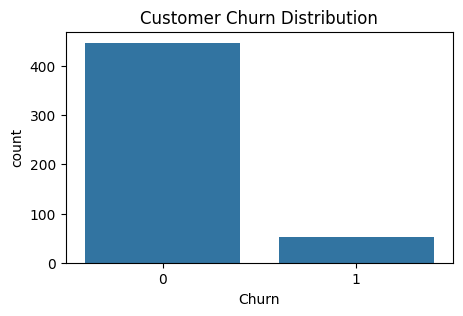

In [9]:
# Visualizing Target Variable
# Churn count plot

plt.figure(figsize=(5,3))
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

In [10]:
# Check object columns

df.select_dtypes(include='object').columns

Index(['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling'], dtype='object')

In [11]:
#  Convert Numeric Columns
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
# Save Cleaned Dataset
df.to_csv('/content/raw_data.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
#  Checking Column Names
df.columns.tolist()

['CustomerID',
 'Tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Contract',
 'PaymentMethod',
 'PaperlessBilling',
 'SeniorCitizen',
 'Churn']

In [14]:
#  Checking Missing Values
# Missing values count
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,0
Tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
PaymentMethod,0
PaperlessBilling,0
SeniorCitizen,0
Churn,0


From the Above Output : We can tell that, **There is No missing values in the raw dataset .**

In [15]:
#  Checking for Unique Values

for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: CustomerID
['C00001' 'C00002' 'C00003' 'C00004' 'C00005' 'C00006' 'C00007' 'C00008'
 'C00009' 'C00010' 'C00011' 'C00012' 'C00013' 'C00014' 'C00015' 'C00016'
 'C00017' 'C00018' 'C00019' 'C00020' 'C00021' 'C00022' 'C00023' 'C00024'
 'C00025' 'C00026' 'C00027' 'C00028' 'C00029' 'C00030' 'C00031' 'C00032'
 'C00033' 'C00034' 'C00035' 'C00036' 'C00037' 'C00038' 'C00039' 'C00040'
 'C00041' 'C00042' 'C00043' 'C00044' 'C00045' 'C00046' 'C00047' 'C00048'
 'C00049' 'C00050' 'C00051' 'C00052' 'C00053' 'C00054' 'C00055' 'C00056'
 'C00057' 'C00058' 'C00059' 'C00060' 'C00061' 'C00062' 'C00063' 'C00064'
 'C00065' 'C00066' 'C00067' 'C00068' 'C00069' 'C00070' 'C00071' 'C00072'
 'C00073' 'C00074' 'C00075' 'C00076' 'C00077' 'C00078' 'C00079' 'C00080'
 'C00081' 'C00082' 'C00083' 'C00084' 'C00085' 'C00086' 'C00087' 'C00088'
 'C00089' 'C00090' 'C00091' 'C00092' 'C00093' 'C00094' 'C00095' 'C00096'
 'C00097' 'C00098' 'C00099' 'C00100' 'C00101' 'C00102' 'C00103' 'C00104'
 'C00105' 'C00106' 'C00107' 'C0

In [20]:
#  Fixing the Inconsistent Values

df['PaperlessBilling'] = df['PaperlessBilling'].str.strip().str.lower()
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,no,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,no,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,no,1,0
4,C00005,16,185,1023,One year,Electronic Check,no,1,0


In [21]:
#  Convert Categorical Target Variable
#   Convert to:
#  1 = churn
#  0 = not churn

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [22]:
#  Checking Class Distribution
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,


**Observation :**

Around 10.6% of customers have churned, while 89.4% customers stayed with the company.

This indicates relatively strong customer retention, though the churned customers still represent a significant business risk that should be analyzed further.

In [28]:
# ------ Outlier Detection-----

# 1. Numeric Columns
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols


Index(['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn'], dtype='object')

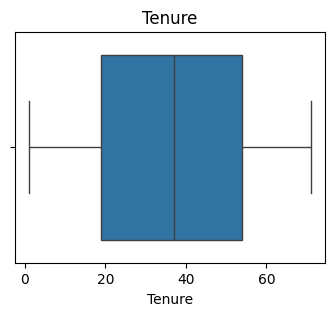

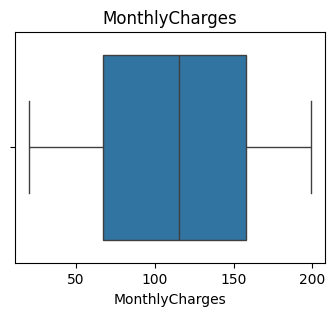

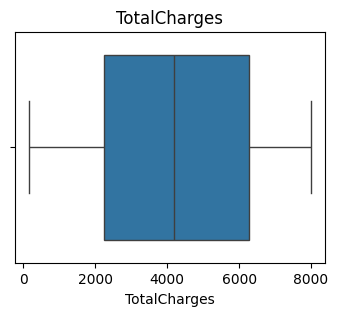

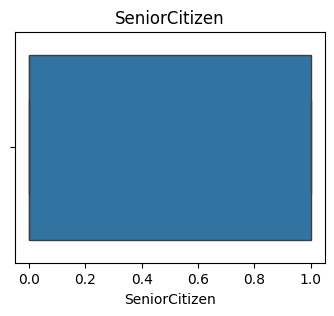

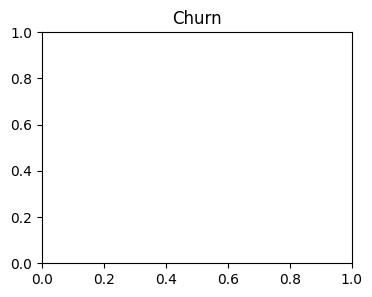

In [30]:
# 2. Boxplots

for col in numeric_cols:

    plt.figure(figsize=(4,3))
    sns.boxplot(x=df[col].dropna())

    plt.title(col)
    plt.show()

In [31]:
#  ----- Final Dataset Checking
df.info()

df.head()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        500 non-null    object 
 1   Tenure            500 non-null    int64  
 2   MonthlyCharges    500 non-null    int64  
 3   TotalCharges      500 non-null    int64  
 4   Contract          500 non-null    object 
 5   PaymentMethod     500 non-null    object 
 6   PaperlessBilling  500 non-null    object 
 7   SeniorCitizen     500 non-null    int64  
 8   Churn             0 non-null      float64
dtypes: float64(1), int64(4), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,0.0
mean,36.532000,113.636000,4237.882000,0.498000,NaN
std,20.667057,51.799903,2260.619837,0.500497,NaN
min,1.000000,20.000000,159.000000,0.000000,NaN
25%,19.000000,67.000000,2237.250000,0.000000,NaN
50%,37.000000,115.000000,4182.500000,0.000000,NaN
75%,54.000000,158.000000,6266.750000,1.000000,NaN
max,71.000000,199.000000,7992.000000,1.000000,NaN


In [32]:
# Saveing Cleaned Dataset
df.to_csv('cleaned_data.csv', index=False)